# Вычислительные графы в PyTorch

## 1. Многослойные сети со skip-соединениями

В глубоких сетях градиент при обратном распространении может затухать, из-за чего нижние слои обучаются плохо. Skip-соединения дают прямой путь на вычислительном графе от входа к более глубоким слоям и обратно.

Skip-соединения — один из самых распространённых приёмов в проектировании нейронных сетей: residual connections в ResNet, skip в U-Net, идеи в DenseNet и в трансформерах. Умение задавать и использовать такие связи важно для понимания современных архитектур.




**Пример 1.1** Создайте блок с residual connection: один вход, выход = σ(linear(h)) + shortcut(h). Shortcut — проекция в out_dim при in_dim ≠ out_dim, иначе тождественное отображение.

**Пример 1.2** Создайте модуль из трех блоков: второй принимает выход первого, третий выход второго. Выход модуля определяется как линейное отображение конкатенации выходов всех блоков в R.


In [ ]:
import torch
import torch.nn as nn


# --- Example 1.1: block with residual connection ---
# output = sigma(linear(h)) + shortcut(h); shortcut = projection if in_dim != out_dim else identity
class ResBlock(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)
        self.shortcut = nn.Linear(in_dim, out_dim) if in_dim != out_dim else nn.Identity()

    def forward(self, h):
        return torch.relu(self.linear(h)) + self.shortcut(h)


# --- Example 1.2: three blocks, output = linear(concat(h0, h1, h2)) -> R ---
# h0 = block0(x), h1 = block1(h0), h2 = block2(h1); out in R
class ThreeBlockModule(nn.Module):
    def __init__(self, in_dim, hidden_dim):
        super().__init__()
        self.block0 = ResBlock(in_dim, hidden_dim)
        self.block1 = ResBlock(hidden_dim, hidden_dim)
        self.block2 = ResBlock(hidden_dim, hidden_dim)
        self.head = nn.Linear(3 * hidden_dim, 1)

    def forward(self, x):
        h0 = self.block0(x)
        h1 = self.block1(h0)
        h2 = self.block2(h1)
        out = self.head(torch.cat([h0, h1, h2], dim=-1))
        return out


# check shapes
x = torch.randn(1, 8)
res_block = ResBlock(8, 16)
h_out = res_block(x)
print("Example 1.1 - ResBlock(8, 16) output shape:", h_out.shape)

model_1_2 = ThreeBlockModule(in_dim=8, hidden_dim=16)
y = model_1_2(x)
print("Example 1.2 - ThreeBlockModule output shape (batch, 1):", y.shape)

Example 1.1 - ResBlock(8, 16) output shape: torch.Size([1, 16])
Example 1.2 - ThreeBlockModule output shape (batch, 1): torch.Size([1, 1])


**Задание 1.** Создайте 15-слойный перцептрон со скип-коннекшном и без. Обучите обе сети на регрессии. Выведите распределения норм градиентов на 15-м, 10-м, 5-м и 1-м слоях для обеих нейросетей.

In [3]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

class DeepMLP(nn.Module):
    def __init__(self, depth=15, width=64, use_skip=False):
        super().__init__()
        self.use_skip = use_skip
        self.input_layer = nn.Linear(1, width)

        self.layers = nn.ModuleList([nn.Linear(width, width) for _ in range(depth)])

        self.output_layer = nn.Linear(width, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.input_layer(x))

        for layer in self.layers:
            if self.use_skip:
                x = self.relu(layer(x)) + x
            else:
                x = self.relu(layer(x))

        return self.output_layer(x)
depth = 15
model_simple = DeepMLP(depth=depth, use_skip=False)
model_skip = DeepMLP(depth=depth, use_skip=True)

def get_gradient_norms(model):
    norms = []
    indices = [0, 4, 9, 14]
    for i in indices:
        grad = model.layers[i].weight.grad
        if grad is not None:
            norms.append(grad.norm().item())
        else:
            norms.append(0.0)
    return norms

X = torch.randn(100, 1)
y = X * 2 + 0.5

criterion = nn.MSELoss()

model_simple.zero_grad()
out_s = model_simple(X)
loss_s = criterion(out_s, y)
loss_s.backward()
norms_simple = get_gradient_norms(model_simple)

model_skip.zero_grad()
out_k = model_skip(X)
loss_k = criterion(out_k, y)
loss_k.backward()
norms_skip = get_gradient_norms(model_skip)

print(f"{'Слой':<10} | {'Simple MLP':<15} | {'Skip MLP':<15}")
print("-" * 45)
indices_names = ["Layer 1", "Layer 5", "Layer 10", "Layer 15"]
for name, s_norm, k_norm in zip(indices_names, norms_simple, norms_skip):
    print(f"{name:<10} | {s_norm:<15.8f} | {k_norm:<15.8f}")

Слой       | Simple MLP      | Skip MLP       
---------------------------------------------
Layer 1    | 0.00000661      | 9.93875217     
Layer 5    | 0.00000857      | 14.15590191    
Layer 10   | 0.00029689      | 14.88394833    
Layer 15   | 0.03134645      | 37.68557739    


## 2. Управление вычислительным графом на примере GAN

При реализации современных архитектур нейронных сетей приходится явно управлять вычислительным графом: например, замораживать некоторые веса, разрывать граф. Это легко увидеть в реализации архитектуры GAN

**GAN (Generative Adversarial Network)** — это пара конкурирующих сетей:

**Генератор G**: по вектору шума z (обычно из N(0,I)) выдаёт «поддельную» выборку G(z). Цель — обмануть дискриминатор, т.е. чтобы G(z) выглядели как реальные данные.
**Дискриминатор D**: по точке x (2D в нашем случае) выдаёт один скаляр — (real|x) = σ(D(x)) = 1/(1+e^{-D(x)}). Его задача — отличать реальные x от сгенерированных G(z).


D максимизирует вероятность верно отличить реальные x от поддельных G(z), а G минимизирует вероятность того, что D распознает подделку (то есть по сути максимизирует D(G(z))). На каждом шаге делают по очереди:

1. по батчу реальных данных и по батчу шума z получают реальные и поддельные точки;

2. обновляют D — минимизируют $-\log D(\text{real}) - \log(1 - D(\text{fake}))$; при этом fake от G отрезают от графа (detach), чтобы градиент не шёл в G;

3. обновляют G — минимизируют $-\log D(G(z))$, при этом веса D обычно замораживают, чтобы градиент обновлял только G.


**Пример 2.1** Сгенерируйте 100–200 точек из гауссовского распределения в R^2. Постройте scatter-график выборки.

**Пример 2.2** Реализуйте простой Generator (z_dim=2, один скрытый слой, out_dim=2) и Discriminator (in_dim=2, один скрытый слой, out=1). Подайте тестовый батч и выведите формы выхода генератора и дискриминатора.

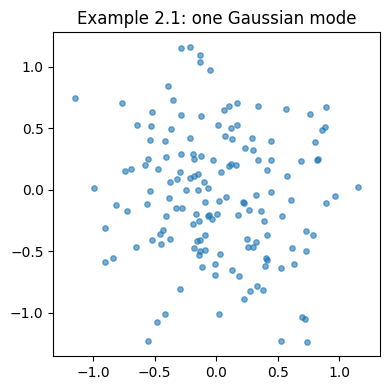

Example 2.2 - G(z) shape: torch.Size([8, 2]) D(x) logits shape: torch.Size([8])


In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# Example 2.1: one Gaussian mode in R^2
n = 150
mean = torch.tensor([0.0, 0.0])
std = 0.5
samples = mean + std * torch.randn(n, 2)
plt.figure(figsize=(4, 4))
plt.scatter(samples[:, 0].numpy(), samples[:, 1].numpy(), alpha=0.6, s=15)
plt.title("Example 2.1: one Gaussian mode")
plt.axis("equal")
plt.tight_layout()
plt.show()

# Example 2.2: minimal G and D, forward shapes
class Generator(nn.Module):
    def __init__(self, z_dim=2, hidden=16, out_dim=2):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(z_dim, hidden), nn.ReLU(), nn.Linear(hidden, out_dim))
    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self, in_dim=2, hidden=16):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim, hidden), nn.ReLU(), nn.Linear(hidden, 1))
    def forward(self, x):
        return self.net(x).squeeze(-1)

G = Generator(z_dim=2, hidden=16, out_dim=2)
D = Discriminator(in_dim=2, hidden=16)
z = torch.randn(8, 2)
x_fake = G(z)
logit_real = D(samples[:8])
logit_fake = D(x_fake.detach())
print("Example 2.2 - G(z) shape:", x_fake.shape, "D(x) logits shape:", logit_real.shape)

**Задание 2.1** Сгенерируйте выборку 2D-точек из мультимодального распределения в R^2 (например, несколько гауссовых мод или смесь колец). Постройте график выборки.

**Задание 2.2** Реализуйте Генератор (MLP: вектор шума z -> 2D точка) и Дискриминатор (MLP: 2D точка -> скалярный logit). Используйте несатурирующую GAN-потерю: генератор минимизирует -log(D(G(z))), дискриминатор минимизирует -log(D(x)) - log(1 - D(G(z))).

**Задание 2.3** Обучите GAN несколько сотен шагов. Постройте график реальных и сгенерированных выборок в конце и по желанию на промежуточных шагах.

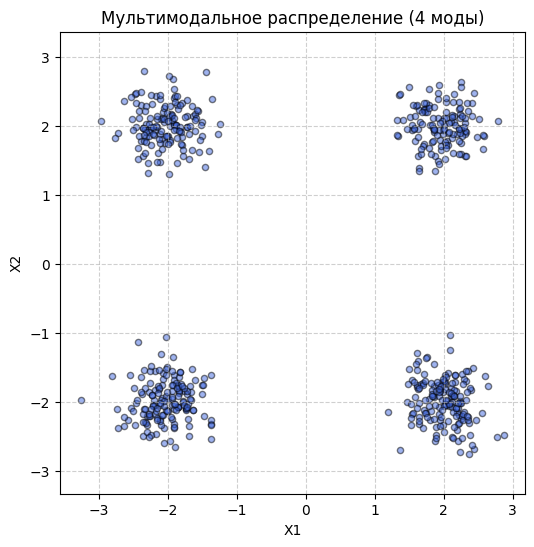

In [6]:
def generate_real_data(n_samples=500):
    centers = [
        [2, 2], [-2, 2], [2, -2], [-2, -2]
    ]
    centers = torch.tensor(centers).float()

    indices = torch.randint(0, len(centers), (n_samples,))
    chosen_centers = centers[indices]

    noise = torch.randn(n_samples, 2) * 0.3
    data = chosen_centers + noise
    return data

real_samples = generate_real_data(600)

plt.figure(figsize=(6, 6))
plt.scatter(real_samples[:, 0], real_samples[:, 1], alpha=0.5, c='royalblue', edgecolors='k', s=20)
plt.title("Мультимодальное распределение (4 моды)")
plt.xlabel("X1")
plt.ylabel("X2")
plt.axis('equal')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim

class Generator(nn.Module):
    def __init__(self, latent_dim, output_dim=2):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim)
        )

    def forward(self, z):
        return self.model(z)

class Discriminator(nn.Module):
    def __init__(self, input_dim=2):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 1) # Выдаем лоджит (без сигмоиды здесь)
        )

    def forward(self, x):
        return self.model(x)



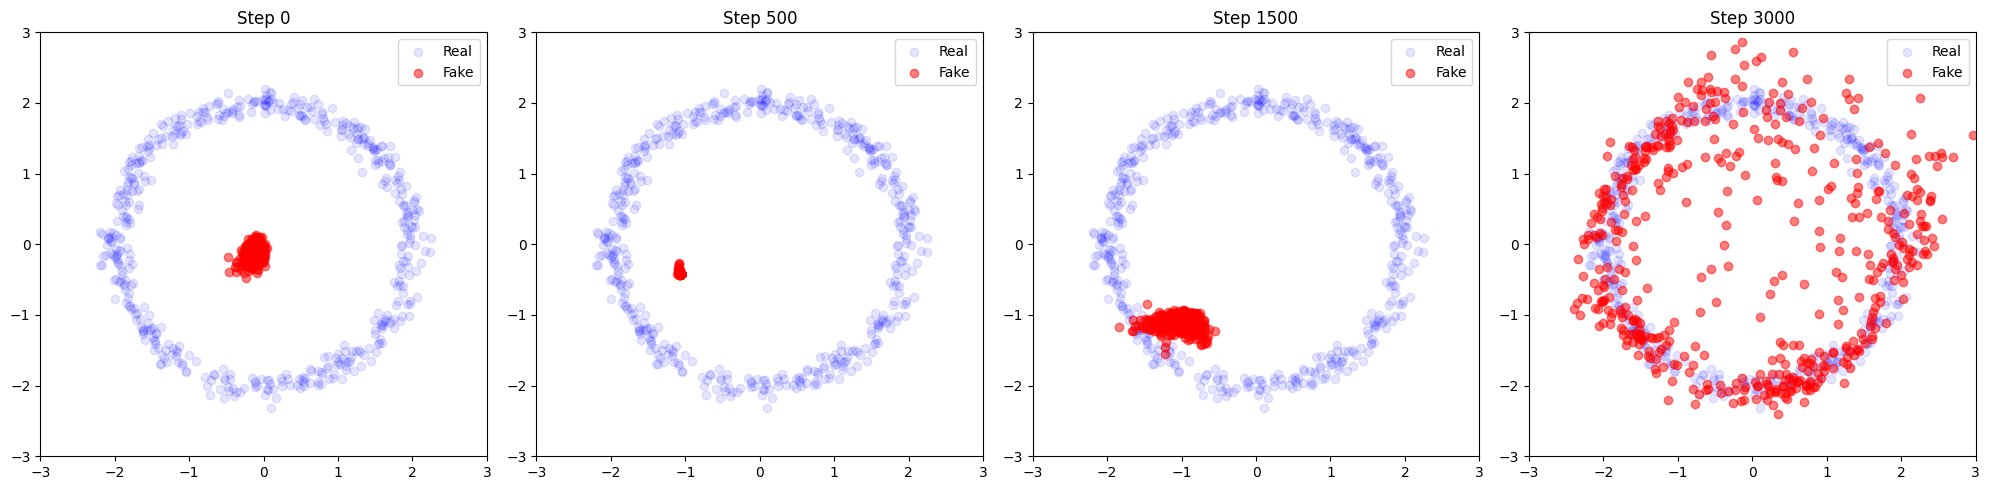

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np


def get_real_samples(n=512):
    theta = torch.rand(n) * 2 * np.pi
    r = 2.0 + torch.randn(n) * 0.1
    x = r * torch.cos(theta)
    y = r * torch.sin(theta)
    return torch.stack((x, y), dim=1)


latent_dim = 8
G = nn.Sequential(
    nn.Linear(latent_dim, 32), nn.ReLU(),
    nn.Linear(32, 32), nn.ReLU(),
    nn.Linear(32, 2)
)
D = nn.Sequential(
    nn.Linear(2, 32), nn.LeakyReLU(0.2),
    nn.Linear(32, 32), nn.LeakyReLU(0.2),
    nn.Linear(32, 1)
)

opt_G = optim.Adam(G.parameters(), lr=0.002)
opt_D = optim.Adam(D.parameters(), lr=0.001)
criterion = nn.BCEWithLogitsLoss()

steps = 3000
history_fake = []
show_at = [0, 500, 1500, 3000]

for step in range(steps + 1):
    # Данные
    real_data = get_real_samples(128)
    z = torch.randn(128, latent_dim)

    # Шаг D
    opt_D.zero_grad()
    fake_data = G(z).detach()
    loss_D = criterion(D(real_data), torch.ones(128, 1)) + \
             criterion(D(fake_data), torch.zeros(128, 1))
    loss_D.backward()
    opt_D.step()

    # Шаг G (Несатурирующий лосс)
    opt_G.zero_grad()
    fake_data_for_G = G(z)
    loss_G = criterion(D(fake_data_for_G), torch.ones(128, 1))
    loss_G.backward()
    opt_G.step()

    # Сохраняем точки для графиков
    if step in show_at:
        with torch.no_grad():
            history_fake.append(G(torch.randn(500, latent_dim)).numpy())

# 4. Визуализация
fig, axes = plt.subplots(1, len(show_at), figsize=(20, 5))
real_plot = get_real_samples(500).numpy()

for i, step in enumerate(show_at):
    axes[i].scatter(real_plot[:, 0], real_plot[:, 1], color='blue', alpha=0.1, label='Real')
    axes[i].scatter(history_fake[i][:, 0], history_fake[i][:, 1], color='red', alpha=0.5, label='Fake')
    axes[i].set_title(f'Step {step}')
    axes[i].set_xlim(-3, 3); axes[i].set_ylim(-3, 3)
    axes[i].legend()

plt.tight_layout()
plt.show()

## 3. Классическая RNN и обратное распространение во времени (BPTT)

Рекуррентная сеть (RNN) обрабатывает последовательности, сохраняя скрытое состояние $h_t$, которое переносит информацию по времени. Классическая RNN задаётся уравнением:

$$h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t + b).$$

Здесь $x_t$ — вход на шаге $t$, $h_{t-1}$ — предыдущее скрытое состояние; $W_{hh}$, $W_{xh}$ и $b$ общие для всех шагов. Выход часто получают как линейное считывание с $h_t$ (или только с $h_T$ в конце).

При обучении сеть разворачивают по времени: одни и те же веса используются на шагах $t=1,\ldots,T$, что даёт вычислительный граф с $T$ копиями ячейки. Градиенты потерь по весам накапливаются по всем шагам — это **обратное распространение во времени (BPTT)**. Градиент из шага $t$ проходит через цепочку $\partial h_t/\partial h_{t-1} \cdots \partial h_1/\partial h_0$; каждый множитель содержит $W_{hh}^\top$ и производную $\tanh$ (по модулю $\le 1$). При больших $T$ или при $\|W_{hh}\|>1$ градиенты могут экспоненциально затухать или взрываться.


**Пример 3.1** Реализуйте одну RNN-ячейку: $h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t + b)$. Подайте тестовые `x` (batch, input_size) и `h_prev` (batch, hidden_size), выведите форму выхода.

**Пример 3.2** Выполните вручную 3 шага по времени: начните с h0=0, на каждом шаге вызывайте ячейку с очередным входом. Выведите список из 4 скрытых состояний (h0, h1, h2, h3) и их формы.

In [ ]:
import torch
import torch.nn as nn

# Example 3.1: single RNN cell
class VanillaRNNCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.W_xh = nn.Linear(input_size, hidden_size)
        self.W_hh = nn.Linear(hidden_size, hidden_size)
    def forward(self, x, h_prev):
        return torch.tanh(self.W_xh(x) + self.W_hh(h_prev))

cell = VanillaRNNCell(input_size=3, hidden_size=4)
batch = 2
x = torch.randn(batch, 3)
h_prev = torch.randn(batch, 4)
h_next = cell(x, h_prev)
print("Example 3.1 - cell output shape:", h_next.shape)

# Example 3.2: 3 steps unrolled by hand
T = 3
x_seq = torch.randn(batch, T, 3)
h = torch.zeros(batch, 4)
h_list = [h]
for t in range(T):
    h = cell(x_seq[:, t], h)
    h_list.append(h)
print("Example 3.2 - number of states (h0..h3):", len(h_list), "each shape:", h_list[-1].shape)

Example 3.1 - cell output shape: torch.Size([2, 4])
Example 3.2 - number of states (h0..h3): 4 each shape: torch.Size([2, 4])


**Задание 3** Реализуйте свою RNN. Сгенерируйте выборку последовательностей из косинусов разной частоты (например, несколько частот в заданном диапазоне) и обучите RNN предсказывать следующее значение по предыдущим.

Epoch 0, Loss: 0.592534
Epoch 200, Loss: 0.000034
Epoch 400, Loss: 0.000144
Epoch 600, Loss: 0.000108
Epoch 800, Loss: 0.000014
Epoch 1000, Loss: 0.000041


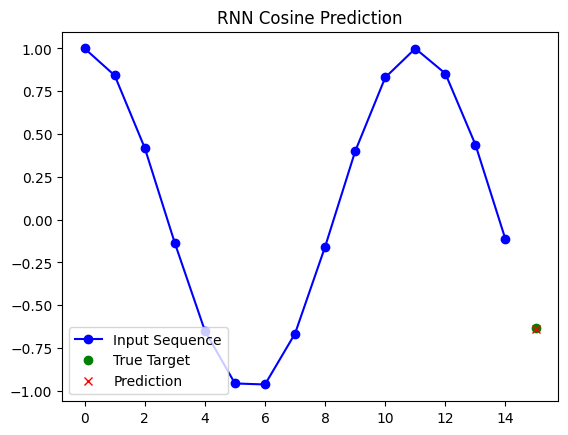

In [11]:
def generate_cosine_waves(batch_size, seq_len):
    frequencies = torch.rand(batch_size, 1) * 1.5 + 0.5
    t = torch.linspace(0, 10, seq_len + 1)

    time_steps = t.repeat(batch_size, 1) * frequencies
    data = torch.cos(time_steps)

    return data[:, :-1].unsqueeze(-1), data[:, -1].unsqueeze(-1)

class CustomRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.hidden_size = hidden_size

        # Веса W_xh, W_hh и b_h (объединены в Linear для удобства)
        self.rnn_cell = nn.Linear(input_size + hidden_size, hidden_size)
        # Слой считывания для предсказания (Readout)
        self.fc = nn.Linear(hidden_size, output_size)
        self.tanh = nn.Tanh()

    def forward(self, x):
        batch_size, seq_len, _ = x.size()

        h_t = torch.zeros(batch_size, self.hidden_size).to(x.device)

        for t in range(seq_len):
            x_t = x[:, t, :]
            combined = torch.cat((x_t, h_t), dim=1)
            h_t = self.tanh(self.rnn_cell(combined))

        out = self.fc(h_t)
        return out

input_dim = 1
hidden_dim = 32
output_dim = 1
seq_length = 15

model = CustomRNN(input_dim, hidden_dim, output_dim)
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

for epoch in range(1001):
    X, Y = generate_cosine_waves(64, seq_length)

    optimizer.zero_grad()
    predictions = model(X)
    loss = criterion(predictions, Y)
    loss.backward()

    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

    optimizer.step()

    if epoch % 200 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

model.eval()
with torch.no_grad():
    test_x, test_y = generate_cosine_waves(1, seq_length)
    pred_y = model(test_x)

    plt.plot(range(seq_length), test_x[0].numpy(), 'b-o', label="Input Sequence")
    plt.plot(seq_length, test_y[0].numpy(), 'go', label="True Target")
    plt.plot(seq_length, pred_y[0].numpy(), 'rx', label="Prediction")
    plt.title("RNN Cosine Prediction")
    plt.legend()
    plt.show()